# Superconducting Qubit Emulation

A resonator can carry an excitation between superconducting qubits. How much
reaches the receiving qubit, and how does noise affect the transfer? We model
two transmons coupled through a resonator, follow their populations, and compare
several relaxation and dephasing strengths. Keeping a third transmon level also
lets us track occupation outside the qubit computational subspace.

This guide uses the standard YAQS installation and Matplotlib. Run the cells in
order in a notebook. For a script, use the entry-point guard in
{doc}`simulator_initialization`.

## 1. Build the transmon–resonator model

`Hamiltonian.coupled_transmon` places transmons at even sites and resonators at
odd sites. Here, sites 0 and 2 are three-level transmons, and site 1 is a
four-level resonator. Each transmon has a Duffing term
$\omega_q n+\alpha n(n-1)/2$, while the resonator has energy $\omega_r n$.
Neighboring sites interact through the full dipole coupling
$g(b+b^\dagger)(a+a^\dagger)$, where $b$ and $a$ lower the transmon and
resonator levels.

In [1]:
import numpy as np

from mqt.yaqs import Hamiltonian

qubit_dim = 3
resonator_dim = 4
physical_dimensions = [qubit_dim, resonator_dim, qubit_dim]
coupling = 1.0
hamiltonian = Hamiltonian.coupled_transmon(
    length=3,
    qubit_dim=qubit_dim,
    resonator_dim=resonator_dim,
    qubit_freq=20.0 * coupling,
    resonator_freq=20.0 * coupling,
    anharmonicity=-1.5 * coupling,
    coupling=coupling,
)
transfer_time = np.pi / (np.sqrt(2) * coupling)

We use $\hbar=1$ and measure frequencies and rates in units of $g$, so time is
in units of $1/g$. The frequency arguments enter the Hamiltonian directly:
convert ordinary frequencies to angular frequencies before supplying dimensional
values. YAQS adds no factor of $2\pi$.

On resonance, $T=\pi/(\sqrt{2}g)$ estimates the first complete transfer in the
rotating-wave approximation. The factory retains counter-rotating terms, so
transfer at this time is approximate and total excitation is not exactly
conserved. This is a model of excitation transfer; one prepared state does not
validate a SWAP gate on arbitrary inputs.

## 2. Excite the left transmon

Start in $|100\rangle$: the left transmon is excited, while the resonator and
right transmon start in their ground states. Characters in `basis_string` follow
site order, starting at site 0.

In [2]:
from mqt.yaqs import State

state = State(
    3, initial="basis", basis_string="100", physical_dimensions=physical_dimensions,
)

The explicit dimensions must match the Hamiltonian. YAQS uses an MPS by default
and supports different local dimensions within the same chain.

## 3. Choose populations and the time grid

Use local matrix observables to measure each site's $|1\rangle$ population. On
the transmons, also measure $|2\rangle$ population to detect leakage from the
computational subspace. Mean occupation $\langle n\rangle$ on all three sites
lets us track total excitation.

In [3]:
from mqt.yaqs import AnalogSimParams, Observable

observables = [
    Observable(np.diag(np.arange(dim) == 1).astype(float), site)
    for site, dim in enumerate(physical_dimensions)
]
observables += [Observable(np.diag([0.0, 0.0, 1.0]), site) for site in (0, 2)]
observables += [
    Observable(np.diag(np.arange(dim)).astype(float), site)
    for site, dim in enumerate(physical_dimensions)
]
params = AnalogSimParams(
    observables=observables,
    elapsed_time=transfer_time,
    dt=transfer_time / 80,
    order=2,
    num_traj=24,
    preset="balanced",
    random_seed=7,
)

Each matrix matches its site's dimension. The observable order is three
$|1\rangle$ populations, two transmon $|2\rangle$ populations, then three mean
occupations. Binary bitstring observables and shot counts require an all-qubit
state; local matrix observables also work with higher levels.

The grid contains 81 samples over one transfer interval. The `balanced` preset
sets numerical tolerances; `order=2` selects second-order TJM for noisy runs.
Each noisy calculation averages 24 trajectories. Sampling error, timestep error,
and the chosen level cutoffs need separate convergence checks.

## 4. Follow the noiseless transfer

Initialize the simulator separately and omit a noise model for the baseline.
YAQS preserves the input state, so subsequent runs can reuse the same
preparation.

In [4]:
from mqt.yaqs import Simulator

simulator = Simulator(show_progress=False)
noiseless = simulator.run(state, hamiltonian, params)
times = noiseless.times
values = np.asarray(noiseless.expectation_values)
print(f"Right transmon population at T: {values[2, -1]:.3f}")

Right transmon population at T: 0.996


`values` has shape `(8, 81)`: observables by sampled times. The first three rows
show the excitation moving through the chain. Rows 3 and 4 measure leakage on
the left and right transmons. Their sum is the expected number of transmons in
$|2\rangle$, rather than the probability that either transmon has leaked. The
resonator's higher photon states are not qubit leakage.

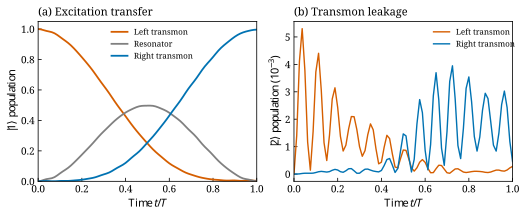

In [5]:
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

set_matplotlib_formats("svg")
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["STIXGeneral"], "mathtext.fontset": "stix",
    "font.size": 10, "axes.labelsize": 11, "axes.linewidth": 0.8,
    "xtick.direction": "in", "ytick.direction": "in", "svg.fonttype": "none",
    "legend.frameon": False,
})
scaled_times = times / transfer_time
site_labels = ["Left transmon", "Resonator", "Right transmon"]
site_colors = ["#D55E00", "0.5", "#0072B2"]
fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9), layout="constrained")
for site, label, color in zip(range(3), site_labels, site_colors, strict=True):
    axes[0].plot(scaled_times, values[site], color=color, linewidth=1.8, label=label)
for row, label, color in ((3, "Left transmon", site_colors[0]), (4, "Right transmon", site_colors[2])):
    axes[1].plot(scaled_times, 1e3 * values[row], color=color, linewidth=1.4, label=label)
axes[0].set(ylabel=r"$|1\rangle$ population", ylim=(0, 1.05))
axes[1].set(ylabel=r"$|2\rangle$ population ($10^{-3}$)")
for ax, title in zip(axes, ["(a) Excitation transfer", "(b) Transmon leakage"], strict=True):
    ax.set(xlabel=r"Time $t/T$", xlim=(0, 1))
    ax.set_title(title, loc="left", fontsize=11)
    ax.legend(fontsize=8)
plt.show()

**The resonator mediates transfer between the transmons.** The resonator
population rises and falls while the receiving transmon approaches unit
population near $T$. Small, rapid excursions into $|2\rangle$ remain visible on
the separate linear scale. The full dipole interaction permits these excursions
even from a single-excitation preparation. The plotted receiver population does
not measure the fidelity of an arbitrary transferred quantum state.

## 5. Add multilevel relaxation and dephasing

The built-in `lowering` and `pauli_z` channels are two-dimensional. For a
three-level transmon, supply explicit matrices. The annihilation matrix $b$
relaxes $|1\rangle$ to $|0\rangle$ and $|2\rangle$ to $|1\rangle$, with the
oscillator's $\sqrt{2}$ matrix element. The number operator $n$ produces pure
dephasing without directly changing populations.

In [6]:
from mqt.yaqs import NoiseModel

lowering = np.diag(np.sqrt(np.arange(1, qubit_dim)), k=1)
number = np.diag(np.arange(qubit_dim)).astype(float)
relaxation_rates = coupling * np.array([0.05, 0.15, 0.6])
results = {0.0: noiseless}
for rate in relaxation_rates:
    noise = NoiseModel(
        [{"name": "relaxation", "sites": [site], "strength": rate, "matrix": lowering}
         for site in (0, 2)]
        + [{"name": "dephasing", "sites": [site], "strength": 2 * rate, "matrix": number}
           for site in (0, 2)]
    )
    results[rate] = simulator.run(state, hamiltonian, params, noise)

`strength` is a Lindblad rate: YAQS multiplies each supplied matrix by
`sqrt(strength)`. Here the jumps are $\sqrt{\gamma}\,b$ and $\sqrt{2\gamma}\,n$.
For an isolated transmon's $|0\rangle$–$|1\rangle$ transition, the relaxation
and pure-dephasing times are both $1/\gamma$. The sweep increases both channels
together and leaves the resonator noise-free. These deliberately short coherence
times make the competition with transfer visible; the parameters are
illustrative, rather than a fit to a device.

Parallel execution is enabled by default. The documentation suppresses progress
bars with `show_progress=False`; omit that setting to see progress. The seed
fixes random streams for repeated runs with the same configuration.

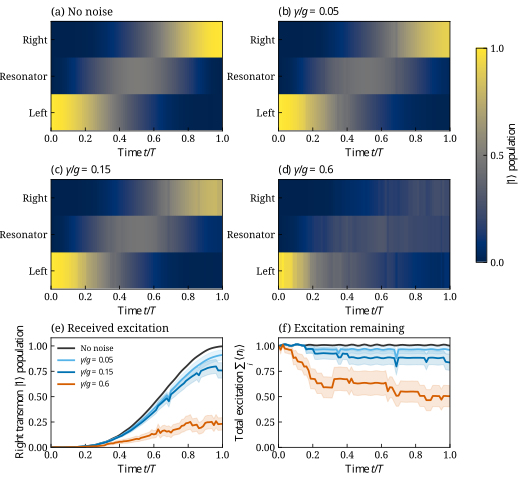

In [7]:
from matplotlib.colors import Normalize

colors = ["0.2", "#56B4E9", "#0072B2", "#D55E00"]
fig, axes = plt.subplots(3, 2, figsize=(7.2, 6.6), layout="constrained")
for index, (ax, (rate, result)) in enumerate(zip(axes[:2].flat, results.items(), strict=True)):
    means = np.asarray(result.expectation_values)
    image = ax.pcolormesh(scaled_times, np.arange(3), means[:3], shading="auto",
                          cmap="cividis", norm=Normalize(0, 1), rasterized=True)
    title = "(a) No noise" if index == 0 else rf"({chr(97 + index)}) $\gamma/g={rate / coupling:g}$"
    ax.set(xlabel=r"Time $t/T$", yticks=[0, 1, 2], yticklabels=["Left", "Resonator", "Right"], xlim=(0, 1))
    ax.set_title(title, loc="left", fontsize=11)
fig.colorbar(image, ax=list(axes[:2].flat), label=r"$|1\rangle$ population", ticks=[0, 0.5, 1], shrink=0.8)

for (rate, result), color in zip(results.items(), colors, strict=True):
    means = np.asarray(result.expectation_values)
    trajectories = np.asarray(result.trajectories)
    label = "No noise" if rate == 0 else rf"$\gamma/g={rate / coupling:g}$"
    for ax, mean, samples in (
        (axes[2, 0], means[2], trajectories[2]),
        (axes[2, 1], means[5:8].sum(axis=0), trajectories[5:8].sum(axis=0)),
    ):
        ax.plot(scaled_times, mean, color=color, linewidth=1.8, label=label)
        if samples.shape[0] > 1:
            standard_error = samples.std(axis=0, ddof=1) / np.sqrt(samples.shape[0])
            ax.fill_between(scaled_times, mean - standard_error, mean + standard_error, color=color, alpha=0.15)
axes[2, 0].set(ylabel=r"Right transmon $|1\rangle$ population")
axes[2, 1].set(ylabel=r"Total excitation $\sum_i\langle n_i\rangle$")
for ax, title in zip(axes[2], ["(e) Received excitation", "(f) Excitation remaining"], strict=True):
    ax.set(xlabel=r"Time $t/T$", xlim=(0, 1), ylim=(0, 1.08))
    ax.set_title(title, loc="left", fontsize=11)
axes[2, 0].legend(fontsize=8, loc="upper left")
plt.show()

**Stronger noise suppresses transfer to the right transmon.** Relaxation removes
excitation, while dephasing disrupts the coherent exchange through the
resonator. The lower panels separate received population from total excitation;
the latter can have small coherent excursions because of the counter-rotating
terms. All heatmaps use one color scale. Shading shows one standard error from
the trajectory samples, with sites summed within each trajectory before
estimating uncertainty in total excitation. These bands measure sampling
uncertainty, not numerical or level-cutoff error.

## Further options

Increase `num_traj` to reduce sampling fluctuations and refine `dt` and
numerical tolerances to check propagation accuracy. Increase `qubit_dim` and
`resonator_dim` separately to check level truncation, rebuilding the state,
observables, and jump matrices to match. Three transmon levels suffice to
illustrate leakage here; they do not establish convergence for a driven device.

To add photon loss, supply a resonator-sized annihilation matrix at site 1.
Other custom channels and distributed strengths are described in
{doc}`realistic_noise_models`. See {doc}`hamiltonians` for longer alternating
chains, {doc}`state_initialization` for other preparations, and
{doc}`simulation_parameters` for accuracy and trajectory settings.